In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Shape:", df.shape)

Shape: (541909, 8)


In [6]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


In [10]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [11]:
df = df.dropna(subset=["CustomerID"])

print("Shape after removing missing CustomerID:", df.shape)

Shape after removing missing CustomerID: (406829, 8)


In [12]:
print("Duplicates Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 5225
Duplicates After: 0


In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[ns]


In [14]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Shape after removing cancelled orders:", df.shape)

Shape after removing cancelled orders: (392732, 8)


In [15]:
df = df[df["Quantity"] > 0]

print(df.shape)

(392732, 8)


In [16]:
df = df[df["UnitPrice"] > 0]

print(df.shape)

(392692, 8)


In [17]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [18]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [20]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [21]:
print("RFM Shape:", rfm.shape)

rfm.describe()

RFM Shape: (4338, 3)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [22]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

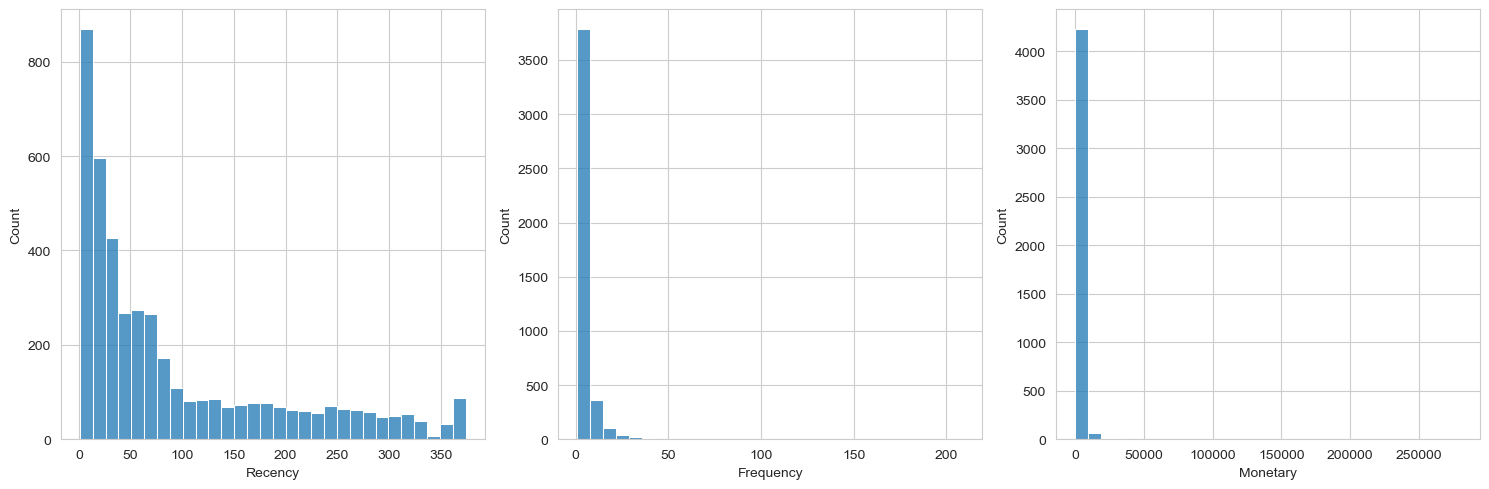

In [23]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm["Recency"], bins=30)

plt.subplot(1,3,2)
sns.histplot(rfm["Frequency"], bins=30)

plt.subplot(1,3,3)
sns.histplot(rfm["Monetary"], bins=30)

plt.tight_layout()

plt.savefig("images/rfm_distribution.png")

plt.show()

In [24]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled.shape)

(4338, 3)


In [25]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

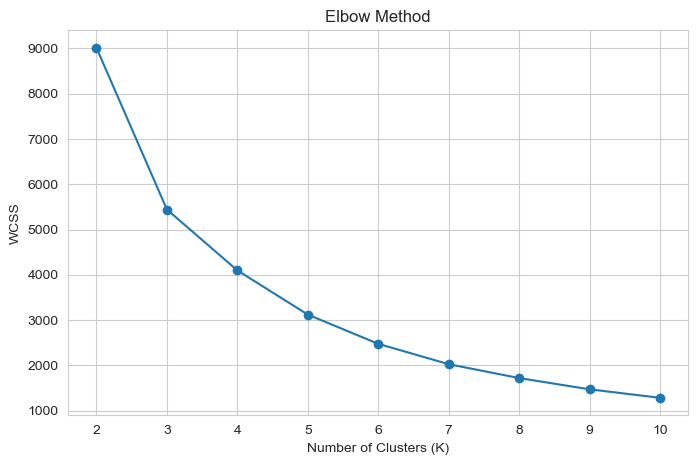

In [26]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.savefig("images/elbow_method.png")

plt.show()

In [27]:
scores = []

for k in range(2,11):

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.8958
K = 3, Silhouette Score = 0.5942
K = 4, Silhouette Score = 0.6162
K = 5, Silhouette Score = 0.6165
K = 6, Silhouette Score = 0.5983
K = 7, Silhouette Score = 0.5165
K = 8, Silhouette Score = 0.4859
K = 9, Silhouette Score = 0.4784
K = 10, Silhouette Score = 0.4792


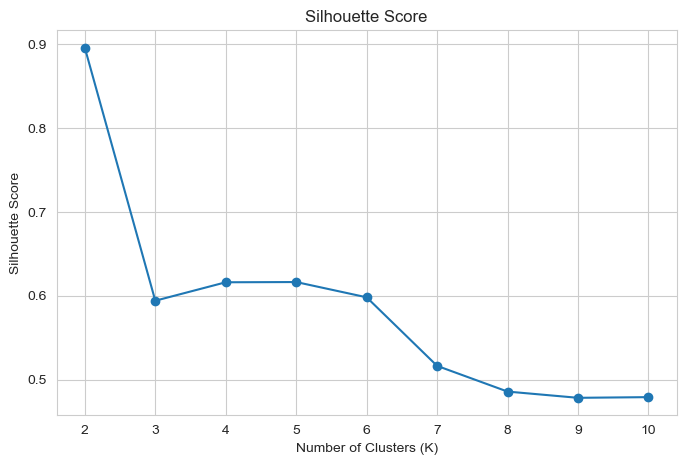

In [28]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker="o")

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.savefig("images/silhouette_score.png")

plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [30]:
rfm["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

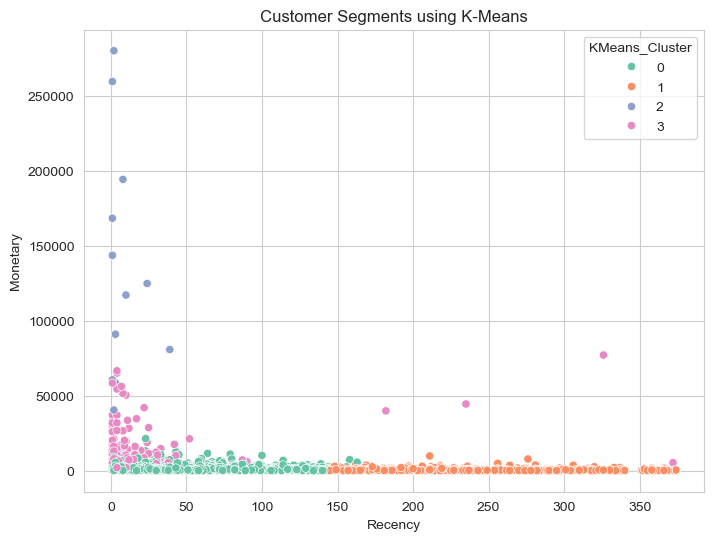

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="KMeans_Cluster",
    palette="Set2"
)

plt.title("Customer Segments using K-Means")

plt.savefig("images/kmeans_clusters.png")

plt.show()

In [32]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster,DBSCAN_Cluster
CustomerID,,,,,
12346.0,326,1,77183.60,3,-1
12347.0,2,7,4310.00,0,0
12348.0,75,4,1797.24,0,0
12349.0,19,1,1757.55,0,0
12350.0,310,1,334.40,1,0


In [33]:
rfm["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1      41
 0    4297
Name: count, dtype: int64